In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../src"))

from black_scholes_merton import price_option_bsm
from monte_carlo import price_option_mc

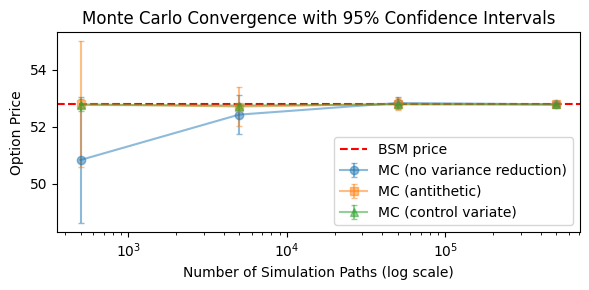

In [5]:
# parameters
seed = None

s = 100
k = 50
r = 0.1
sigma = 0.25
T = 1
q = 0.02

option_type = 'call'
exercise_style = 'European'

N_paths = np.asarray([500, 5000, 50000, 500000])

price1, price2, price3 = np.zeros(len(N_paths)), np.zeros(len(N_paths)), np.zeros(len(N_paths))
std1, std2, std3 = np.zeros(len(N_paths)), np.zeros(len(N_paths)), np.zeros(len(N_paths))

for i, n_paths in enumerate(N_paths):
    # without antithetic
    price1[i], std1[i] = price_option_mc(option_type, exercise_style, s, k, r, sigma, T, q, n_paths, 
                          antithetic=False, control_variate=False, seed=seed)
    # with antithetic
    price2[i], std2[i] = price_option_mc(option_type, exercise_style, s, k, r, sigma, T, q, n_paths, 
                          antithetic=True, control_variate=False, seed=seed)
    # with control variate
    price3[i], std3[i] = price_option_mc(option_type, exercise_style, s, k, r, sigma, T, q, n_paths, 
                          antithetic=False, control_variate=True, seed=seed)

price_bsm = price_option_bsm(option_type, exercise_style, s, k, r, sigma, T, q)

# 95% confidence level
ci1 = 1.96*std1
ci2 = 1.96*std2
ci3 = 1.96*std3

plt.figure(figsize=(6,3))

plt.errorbar(N_paths, price1, yerr=ci1, fmt='o-', capsize=2, alpha=0.5,
             label='MC (no variance reduction)')

plt.errorbar(N_paths, price2, yerr=ci2, fmt='s-', capsize=2, alpha=0.5,
             label='MC (antithetic)')

plt.errorbar(N_paths, price3, yerr=ci3, fmt='^-', capsize=2, alpha=0.5,
             label='MC (control variate)')

plt.axhline(price_bsm, linestyle='--', color='red',
            label='BSM price')

plt.xscale('log')

plt.xlabel('Number of Simulation Paths (log scale)')
plt.ylabel('Option Price')
plt.title('Monte Carlo Convergence with 95% Confidence Intervals')
#plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
std1, std2, std3

(array([1.13215932, 0.35064906, 0.1114735 , 0.03517063]),
 array([1.12469306, 0.34674362, 0.11165329, 0.03518275]),
 array([0.11480498, 0.03713695, 0.01177362, 0.00370615]))